# HOG + SVM vs SimpleCNN on CIFAR-10

## 1. Loading CIFAR-10
This section loads CIFAR-10 and prepares tensors for further processing.

In [4]:
# !pip install scikit-image

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root="./data", train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root="./data", train=False,
                                       download=True, transform=transform)

X_train = trainset.data
y_train = np.array(trainset.targets)
X_test = testset.data
y_test = np.array(testset.targets)

print("Train shape:", X_train.shape)


100.0%


Train shape: (50000, 32, 32, 3)


## 2. HOG Feature Extraction
We extract HOG descriptors from grayscale versions of CIFAR-10 images.

In [ ]:

N_train, N_test = 2000, 500
X_train_small, y_train_small = X_train[:N_train], y_train[:N_train]
X_test_small, y_test_small = X_test[:N_test], y_test[:N_test]

def compute_hog_features(img):
    
    # Averages the RGB channels to collapse the 3‑channel image into a single 2D grayscale array. 
    # HOG expects intensity values, so taking np.mean(..., axis=2) converts the color image to a grayscale
    # representation before extracting HOG features.
    img_gray = np.mean(img, axis=2)
    
    # Compute HOG features
    features = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys')
    
    return features

hog_train = np.array([compute_hog_features(img) for img in X_train_small])
hog_test = np.array([compute_hog_features(img) for img in X_test_small])

print("HOG vector length:", hog_train.shape[1])


HOG vector length: 324


## 3. Training SVM on HOG Features
We now classify HOG features using a Linear SVM.

In [7]:

svm_clf = make_pipeline(StandardScaler(), LinearSVC(C=1.0, max_iter=5000))
svm_clf.fit(hog_train, y_train_small)
y_pred_hog = svm_clf.predict(hog_test)

acc_hog = accuracy_score(y_test_small, y_pred_hog)
print("HOG + SVM accuracy:", acc_hog)
print(classification_report(y_test_small, y_pred_hog))


HOG + SVM accuracy: 0.362
              precision    recall  f1-score   support

           0       0.38      0.44      0.41        57
           1       0.45      0.49      0.47        41
           2       0.27      0.27      0.27        51
           3       0.34      0.37      0.35        49
           4       0.36      0.40      0.38        40
           5       0.26      0.21      0.23        48
           6       0.37      0.35      0.36        54
           7       0.40      0.43      0.41        47
           8       0.35      0.26      0.30        57
           9       0.41      0.43      0.42        56

    accuracy                           0.36       500
   macro avg       0.36      0.36      0.36       500
weighted avg       0.36      0.36      0.36       500



## 4. Defining a CNN and Training It
We train a simple CNN for comparison against HOG+SVM.

In [8]:

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.fc(x)
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128, shuffle=False)

for epoch in range(2):
    model.train()
    running = 0
    for imgs, labels in trainloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running += loss.item()
    print(f"Epoch {epoch+1}, Loss = {running/len(trainloader):.4f}")


Epoch 1, Loss = 1.5686
Epoch 2, Loss = 1.2240


## 5. CNN Evaluation

In [9]:

correct = 0
total = 0
model.eval()
with torch.no_grad():
    for imgs, labels in testloader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc_cnn = correct / total
print("SimpleCNN accuracy:", acc_cnn)


SimpleCNN accuracy: 0.5866


## 6. Feature Map Visualization
We visualize feature maps from the first and second convolution layers.

Label: 3 (cat)


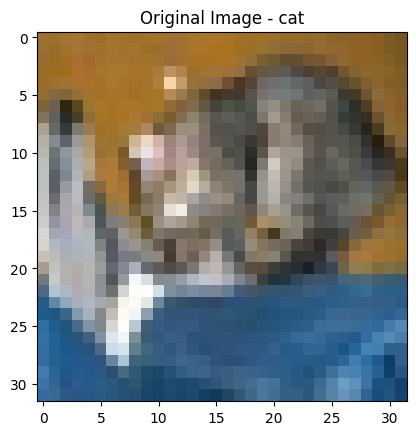

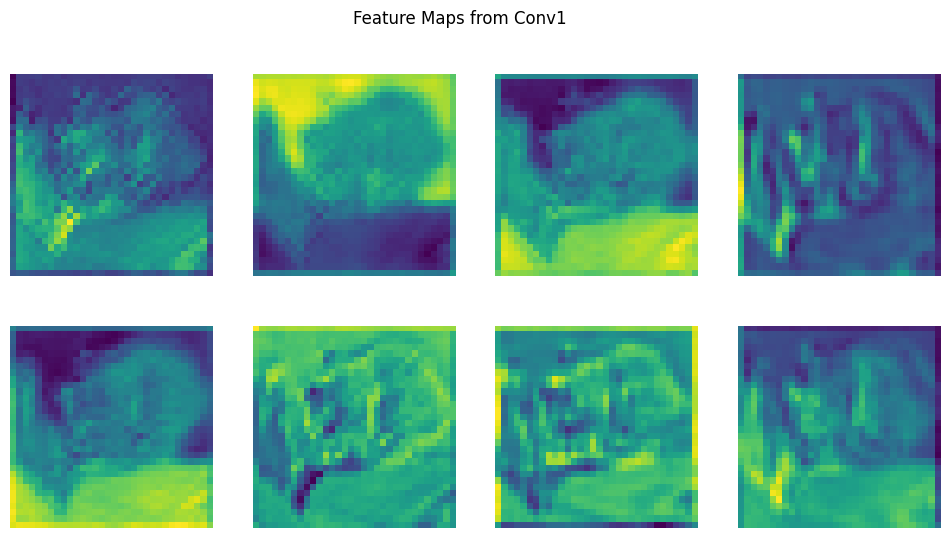

In [12]:

# Hook to capture feature maps
feature_maps = {}

def hook_fn(module, input, output):
    feature_maps[module] = output.detach().cpu()

model.conv1.register_forward_hook(hook_fn)
model.conv2.register_forward_hook(hook_fn)

# Pass a single example
img, label = testset[0]
class_name = testset.classes[label]
print(f"Label: {label} ({class_name})")

plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.title(f"Original Image - {class_name}")
plt.show()

_ = model(img.unsqueeze(0).to(device))

# Visualize first conv layer maps
fm1 = feature_maps[model.conv1][0]

plt.figure(figsize=(12,6))
for i in range(8):  # show first 8 channels
    plt.subplot(2,4,i+1)
    plt.imshow(fm1[i], cmap='viridis')
    plt.axis('off')
plt.suptitle("Feature Maps from Conv1")
plt.show()


### Interpreting the Feature Maps

Each feature map corresponds to the activation of a specific convolutional filter applied to the input image.  
In the first convolutional layer (Conv1), filters typically learn to detect simple, low-level visual patterns such as:

- edges (horizontal, vertical, diagonal)
- intensity gradients
- small texture primitives
- color or brightness transitions

Bright regions in a feature map indicate strong activation, meaning the filter detected the pattern it is tuned for at those spatial locations.  
Dark regions correspond to weak or no activation.

Because CIFAR-10 images are low resolution (32×32), these early feature maps often appear blurry, but they still reveal important information: the network is decomposing the image into basic visual structures.  
Deeper layers will combine these primitive patterns to form more abstract representations relevant for classification.

### How feature maps change when training for more epochs

Training the CNN for only 2 epochs means that the convolutional filters are still in an early, partially random stage of learning. If the model is trained for more epochs, several qualitative changes typically appear in the feature maps:

1. **Sharper and more structured activations**  
   Early maps look blurry or noisy because filters have not yet converged. With more training, edge responses become sharper and texture patterns become more stable.

2. **Greater filter specialization**  
   As training progresses, filters no longer detect similar patterns. Instead, different filters specialize in detecting horizontal edges, vertical edges, diagonal contours, color transitions, or specific textures.

3. **More discriminative responses**  
   The network learns to suppress irrelevant background signals and respond more strongly to class-relevant structures (such as fur texture, ears, or contours in an image of a cat).

4. **Reduced noise and redundancy**  
   With additional training, activations become cleaner and less random, and different feature maps stop looking alike.

In short, training for more epochs leads to clearer, more meaningful, and more diverse feature maps, reflecting the network’s improved ability to extract structure from the input image.


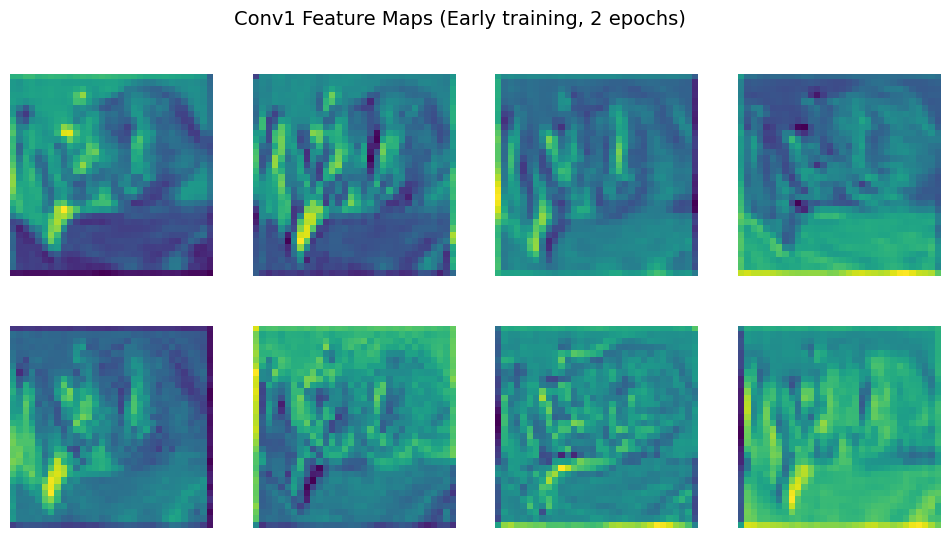

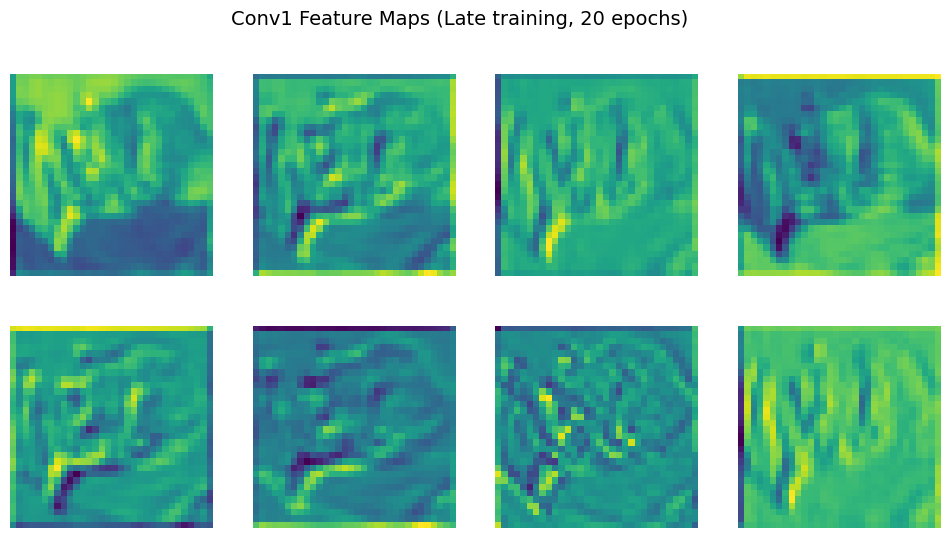

In [13]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Load CIFAR-10 image
# -------------------------------------------------------
transform = transforms.Compose([transforms.ToTensor()])

testset = torchvision.datasets.CIFAR10(root="./data", train=False,
                                       download=True, transform=transform)

img, label = testset[0]   # example image
x = img.unsqueeze(0)       # add batch dimension


# -------------------------------------------------------
# 2. Define the same CNN architecture as before
# -------------------------------------------------------
class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.pool = torch.nn.MaxPool2d(2)
        self.relu = torch.nn.ReLU()
        self.fc = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 8 * 8, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.fc(x)
        return x


# -------------------------------------------------------
# 3. Train two models: early vs late
# -------------------------------------------------------
def train_model(num_epochs):
    model = SimpleCNN()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    trainloader = torch.utils.data.DataLoader(
        torchvision.datasets.CIFAR10(root="./data", train=True,
                                     download=True, transform=transform),
        batch_size=128, shuffle=True
    )

    for epoch in range(num_epochs):
        model.train()
        for imgs, labels in trainloader:
            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()

    return model


model_early = train_model(num_epochs=2)
model_late  = train_model(num_epochs=20)


# -------------------------------------------------------
# 4. Capture feature maps by registering hooks
# -------------------------------------------------------
def get_feature_maps(model, x):
    fmap = {}

    def hook_fn(m, i, o):
        fmap["conv1"] = o.detach()

    model.conv1.register_forward_hook(hook_fn)
    model.eval()
    model(x)
    return fmap["conv1"]  # shape: (1, 32, H, W)

fm_early = get_feature_maps(model_early, x)
fm_late  = get_feature_maps(model_late,  x)


# -------------------------------------------------------
# 5. Visualization: compare early vs late feature maps
# -------------------------------------------------------
def show_feature_maps(fmap, title, num_maps=8):
    fmap = fmap[0]  # remove batch dimension

    plt.figure(figsize=(12,6))
    plt.suptitle(title, fontsize=14)

    for i in range(num_maps):
        plt.subplot(2, 4, i+1)
        plt.imshow(fmap[i].cpu(), cmap="viridis")
        plt.axis("off")

    plt.show()

show_feature_maps(fm_early, "Conv1 Feature Maps (Early training, 2 epochs)")
show_feature_maps(fm_late,  "Conv1 Feature Maps (Late training, 20 epochs)")


### What to expect?

**Early-training feature maps (2 epochs):**
- blurry
- noisy
- low specialization
- weak structure

**Late-training feature maps (20 epochs):**
- sharper responses
- clearer edges
- meaningful texture detectors
- richer diversity across filters

This contrast is extremely useful for illustrating how CNNs learn hierarchical representations over time.

## 7. Accuracy Comparison

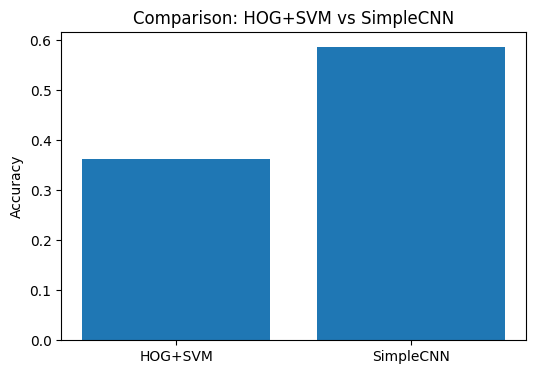

In [11]:

plt.figure(figsize=(6,4))
plt.bar(["HOG+SVM", "SimpleCNN"], [acc_hog, acc_cnn])
plt.ylabel("Accuracy")
plt.title("Comparison: HOG+SVM vs SimpleCNN")
plt.show()
